In [1]:
import time
notebook_start = time.perf_counter()
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker, sys, os, csv, shutil, json
from scipy.optimize import least_squares
from itertools import chain
from si_units import BAR, KELVIN
from pathlib import Path
from feos.eos import EquationOfState, PhaseDiagram
from feos.pcsaft import PcSaftParameters
from feos.eos.estimator import Estimator, Loss, DataSet, Phase
import io, base64

sys.path.append("..")
import PLOT_SETTINGS as ps

plot_dir = Path("PLOTS")
if plot_dir.exists():
    shutil.rmtree(plot_dir)
plot_dir.mkdir()

mixture = "CO-N2"
PLOT    = False
npoints = 100       # for VLE calculations
nfit    = 1000
deg     = 2

In [2]:
def eos_from_kij(kij):
    """Returns equation of state (PC-SAFT) for current kij."""
    global parameters
    p = PcSaftParameters.new_binary(parameters.pure_records, kij)
    return EquationOfState.pcsaft(p)

def cost(kij, estimator):
    """Calculates cost function for current parameters."""
    return estimator.cost(eos_from_kij(kij))

def components(mixture):
    global comp1, comp2
    comp1, comp2 = mixture.split("-")
    
    return comp1, comp2

def poly_to_string(coeffs, var="T", name="k_ij"):
    """
    Build a readable polynomial string from np.polyfit coeffs.
    coeffs are in descending powers: [c_n, ..., c_1, c_0]
    """
    deg     = len(coeffs) - 1
    terms   = []
    for i, coef in enumerate(coeffs):
        power = deg - i
        if power == 0:
            terms.append(f"{coef:.6e}")
        elif power == 1:
            terms.append(f"({coef:.6e})*{var}")
        else:
            terms.append(f"({coef:.6e})*{var}^{power}")
    return f"{name}({var}) = " + " + ".join(terms)

def fit_kij_polynomial(df_best_kij, deg, T_col="Temperature_[K]", kij_col="kij"):
    """
    Fit kij(T) with a polynomial of degree 'deg'.

    Returns:
      coeffs  : np.ndarray of coefficients (descending powers)
      kij_func: np.poly1d callable function
    """
    T_data      = df_best_kij[T_col].to_numpy(dtype=float)
    kij_data    = df_best_kij[kij_col].to_numpy(dtype=float)

    # sort by temperature
    order       = np.argsort(T_data)
    T_data      = T_data[order]
    kij_data    = kij_data[order]

    coeffs      = np.polyfit(T_data, kij_data, deg=deg)
    kij_func    = np.poly1d(coeffs)

    print("\nFitted function:")
    print(poly_to_string(coeffs, var="T", name="k_ij"))
    print("\nnp.poly1d form:\n", kij_func)

    return coeffs, kij_func, T_data, kij_data

def set_custom_xlabel(ax, fontsize=ps.label_fontsize):
    ax.text(0.33, -0.17, r"$x_{\mathrm{N_2}}$",
        color="blue", fontsize=fontsize,transform=ax.transAxes, ha="right")
    ax.text(0.35, -0.17, r"$,$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="center")
    ax.text(0.36, -0.17, r"$y_{\mathrm{N_2}}$",
        color="red", fontsize=fontsize,transform=ax.transAxes, ha="left")
    ax.text(0.49, -0.17, r"$/ \;[{\mathrm{mol} \; \mathrm{mol}^{-1}}]$",
        color="black", fontsize=fontsize,transform=ax.transAxes, ha="left")

def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

In [3]:
def VLE_PLOT(mixture, data, cols, temperature, kij):

    comp1, comp2    = components(mixture)
    isotherm        = data[data[cols["T"]] == temperature]
    
    if isotherm.empty:
        raise ValueError(f"No data available for T = {temperature} K")

    fig, ax = ps.plot_init()
    i = 0
 
    # Experimental data
    if isotherm[cols["Comp"]].iloc[0] == comp2:
        ax.plot(1-isotherm[cols["x1"]], isotherm[cols["P"]],
            color='blue', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#56abff", markeredgewidth=ps.markeredgewidth,
            label=isotherm.source.iloc[0] + f" (T = {temperature} K)")

        ax.plot(1-isotherm[cols["y1"]], isotherm[cols["P"]],
            color='red', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#FF5656", markeredgewidth=ps.markeredgewidth,)
    else:
        ax.plot(isotherm[cols["x1"]], isotherm[cols["P"]],
            color='blue', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize,markerfacecolor="#56abff", markeredgewidth=ps.markeredgewidth,
            label=isotherm.source.iloc[0] + f" (T = {temperature} K)")

        ax.plot(isotherm[cols["y1"]], isotherm[cols["P"]],
            color='red', marker=ps.markers[i % len(ps.markers)],
            linestyle="", markersize=ps.markersize, markerfacecolor="#FF5656", markeredgewidth=ps.markeredgewidth,)

    # PC-SAFT predictions
    vle = PhaseDiagram.binary_vle(eos_from_kij(kij),temperature * KELVIN, npoints)

    ax.plot(vle.vapor.molefracs[:, 1], vle.vapor.pressure / BAR,
        color='red', linewidth=ps.linewidth, linestyle="-",
        label=fr"PC-SAFT ($k_{{ij}} = {kij:.3f}$)")

    ax.plot(vle.liquid.molefracs[:, 1], vle.liquid.pressure / BAR,
        color='blue', linewidth=ps.linewidth, linestyle="-")

    ax.minorticks_on()
    ymax = (vle.liquid.pressure / BAR).max()
    
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    
    if ymax > 140:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(10))
    else:
        ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))

    # ax.set_xlabel(r"$x_{\mathrm{CO_2}}$, $y_{\mathrm{CO_2}}$", fontsize=ps.label_fontsize)
    set_custom_xlabel(ax, fontsize=ps.label_fontsize)
    ax.set_ylabel(r"$P$ / [bar]", fontsize=ps.label_fontsize)
    ax.set_xlim(min(vle.vapor.molefracs[:, 1].min(), vle.liquid.molefracs[:, 1].min())- 0.1, 1.1)
    ax.set_ylim( (vle.liquid.pressure / BAR).min()/1.3, (vle.liquid.pressure / BAR).max() * 1.3)

    ps.style_legend(ax,loc='upper right',ncol=1,borderaxespad=1.0,frame=False)

    legend = ax.get_legend()
    for handle in legend.legend_handles:
        handle.set_color("black")
        handle.set_markerfacecolor("black")
        handle.set_markeredgecolor("black")
        
    ps.save_plot(fig, f"vle_T{int(temperature)}K_kij{kij:.3f}")


In [4]:
parameters  = PcSaftParameters.from_json(["nitrogen", "carbon monoxide"], "../parameters_08.json")
pcsaft = EquationOfState.pcsaft(parameters)
parameters

|component|molarweight|$m$|$\sigma$|$\varepsilon$|$\mu$|$Q$|$\kappa_{AB}$|$\varepsilon_{AB}$|$N_A$|$N_B$|$N_C$|
|-|-|-|-|-|-|-|-|-|-|-|-|
|nitrogen|28.006|1.23831|3.30009|89.41358|-|-|-|-|0|0|0|
|carbon monoxide|27.995|1.32286|3.24532|91.17087|-|-|-|-|0|0|0|

In [5]:
data = pd.read_excel("VLE_CO_N2.xlsx", sheet_name=0)
cols = {
        "P": data.columns[0],
        "x1": data.columns[1],
        "y1": data.columns[2],
        "T": data.columns[3],
        'Comp': data.columns[5]
        }

# data = data[~data[cols["T"]].between(252, 254)].reset_index(drop=True)
# print(data.tail())
# print(data.head())
comp1, comp2    = components(mixture)
print(f"Components: {comp1}, {comp2}")
print(data[cols["T"]].unique())

Components: CO, N2
[ 70.      75.      80.      90.     100.0179 110.0102 120.0022]


In [6]:
data

,P_bar,x,y,T_K,source,x/y Composition
0,0.3850,0.1,0.048,70.0000,"Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...",CO
1,0.3648,0.2,0.113,70.0000,"Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...",CO
2,0.3546,0.3,0.183,70.0000,"Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...",CO
3,0.3344,0.4,0.264,70.0000,"Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...",CO
4,0.3040,0.5,0.342,70.0000,"Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...",CO
...,...,...,...,...,...,...
58,21.8860,0.5,0.465,120.0022,"Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...",CO
59,21.3492,0.6,0.567,120.0022,"Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...",CO
60,20.8628,0.7,0.672,120.0022,"Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...",CO
61,20.3157,0.8,0.775,120.0022,"Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...",CO


In [7]:
if PLOT == True:
    for T in data[cols["T"]].unique():
        VLE_PLOT(mixture, data, cols, T, 0)
        plt.show()

In [8]:
kij_distance = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [float(np.atleast_1d(fitted_kij)[0])]

    print(isotherm)
    
    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
            y = isotherm[cols["y1"]].to_numpy(float)
        else:
            x = 1- isotherm[cols["x1"]].to_numpy(float)
            y = 1- isotherm[cols["y1"]].to_numpy(float)

    isotherms = [DataSet.binary_phase_diagram(T*KELVIN, isotherm[cols["P"]].values * BAR, x, y, npoints)]

    estimator = Estimator(isotherms, weights=[1], losses=[Loss.linear()])
    
    try:
        fitted_kij = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator,), verbose=2).x
        kij_distance.append(float(np.atleast_1d(fitted_kij)[0]))
        kij_distance.append(kij_distance)
        mard_distance = estimator.mean_absolute_relative_difference(eos_from_kij(fitted_kij)) * 100
        mard_distance = mard_distance.mean()
        
    except Exception as e:
        print(f"Optimization failed for T = {T} K: {e}")
        fitted_kij = None
        mard_distance = np.nan
        
    kij_file = os.path.join("PLOTS", "kij_all.csv")
    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["distance", T, float(np.atleast_1d(fitted_kij)[0]) if fitted_kij is not None else np.nan,
         np.nan if np.isnan(mard_distance) else mard_distance])

if fitted_kij is not None:
    kij_val = float(np.atleast_1d(fitted_kij)[0])
    print(f"\033[1mOptimized kij value at T = {T} K: {kij_val:.6f}\033[0m")
    print(f"MARD (distance, k_ij = {kij_val:>6.4f}) = {mard_distance:>8.4f} %")
else:
    print(f"\033[1mOptimization failed at T = {T} K\033[0m")


    P_bar    x      y   T_K  \
0  0.3850  0.1  0.048  70.0   
1  0.3648  0.2  0.113  70.0   
2  0.3546  0.3  0.183  70.0   
3  0.3344  0.4  0.264  70.0   
4  0.3040  0.5  0.342  70.0   
5  0.2938  0.6  0.441  70.0   
6  0.2837  0.7  0.565  70.0   
7  0.2634  0.8  0.695  70.0   
8  0.2432  0.9  0.827  70.0   

                                              source x/y Composition   
0  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
1  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
2  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
3  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
4  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
5  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
6  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
7  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
8  Torocheshnikov, N. Sov. Phys. - Tech. 

/tmp/ipykernel_30290/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)
/tmp/ipykernel_30290/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


       1              2         4.6880e-07      3.88e-07       2.39e-03       3.34e-07    
       2              3         4.6880e-07      1.70e-12       5.05e-06       3.60e-09    
`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 8.5640e-07, final cost 4.6880e-07, first-order optimality 3.60e-09.
     P_bar    x      y   T_K  \
18  1.3679  0.1  0.060  80.0   
19  1.3170  0.2  0.131  80.0   
20  1.2767  0.3  0.216  80.0   
21  1.2463  0.4  0.300  80.0   
22  1.2058  0.5  0.385  80.0   
23  1.1450  0.6  0.500  80.0   
24  1.0842  0.7  0.615  80.0   
25  1.0436  0.8  0.726  80.0   
26  0.9930  0.9  0.851  80.0   

                                               source x/y Composition   
18  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
19  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
20  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
21  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...    

/tmp/ipykernel_30290/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)
/tmp/ipykernel_30290/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.0381e-05                                    1.25e-03    
       1              2         4.5900e-06      2.58e-05       2.10e-02       5.22e-05    
       2              3         4.5375e-06      5.26e-08       1.04e-03       1.05e-06    
       3              4         4.5375e-06      2.15e-11       2.09e-05       1.78e-08    
       4              5         4.5375e-06      6.18e-15       3.57e-07       4.02e-10    
`gtol` termination condition is satisfied.
Function evaluations 5, initial cost 3.0381e-05, final cost 4.5375e-06, first-order optimality 4.02e-10.
     P_bar    x      y       T_K  \
36  7.5990  0.1  0.078  100.0179   
37  7.2447  0.2  0.160  100.0179   
38  7.0016  0.3  0.249  100.0179   
39  6.7890  0.4  0.350  100.0179   
40  6.6165  0.5  0.436  100.0179   
41  6.4443  0.6  0.546  100.0179   
42  6.2315  0.7  0.642  100.0179   
43  6.1200  0.8  0

/tmp/ipykernel_30290/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)
/tmp/ipykernel_30290/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


       1              2         7.2119e-07      8.50e-08       1.59e-03       1.98e-07    
       2              3         7.2119e-07      1.19e-12       5.99e-06       1.72e-09    
`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 8.0616e-07, final cost 7.2119e-07, first-order optimality 1.72e-09.
      P_bar    x      y       T_K  \
54  24.7230  0.1  0.085  120.0022   
55  23.9130  0.2  0.180  120.0022   
56  23.1933  0.3  0.274  120.0022   
57  22.4940  0.4  0.368  120.0022   
58  21.8860  0.5  0.465  120.0022   
59  21.3492  0.6  0.567  120.0022   
60  20.8628  0.7  0.672  120.0022   
61  20.3157  0.8  0.775  120.0022   
62  19.8600  0.9  0.878  120.0022   

                                               source x/y Composition   
54  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
55  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
56  Torocheshnikov, N. Sov. Phys. - Tech. Phys., 1...               CO  
57  Tor

/tmp/ipykernel_30290/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


In [9]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_distance):
        VLE_PLOT(mixture, data, cols, T, kij)
        plt.show()

In [10]:
kij_mu = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
    
    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
            y = isotherm[cols["y1"]].to_numpy(float)
        else:
            x = 1- isotherm[cols["x1"]].to_numpy(float)
            y = 1- isotherm[cols["y1"]].to_numpy(float)
    
    isotherms = [DataSet.binary_vle_chemical_potential(np.array([T]*len(isotherm)) *KELVIN, 
        isotherm[cols["P"]].values * BAR, x, y)]

    estimator_mu = Estimator(isotherms, weights=[1]*3, losses=[Loss.linear()]*3)

    fitted_kij_mu = least_squares(cost, initial_kij, bounds=[-0.5, 0.5], args=(estimator_mu,), verbose=2).x

    kij_mu.append(fitted_kij_mu[0])

    mard_mu = estimator_mu.mean_absolute_relative_difference(eos_from_kij(fitted_kij_mu)) * 100

    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["chemical potential", T, fitted_kij_mu[0], mard_mu.mean()])

    print(f"\033[1mOptimized kij value at T = {T} K: {fitted_kij_mu[0]:.6f}\033[0m")
    print(f"MARD (chem. pot., k_ij = {fitted_kij_mu[0]:>6.4}) = {mard_mu.mean():>8.4} %")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.6828e-07                                    2.06e-05    
       1              2         2.6100e-07      1.07e-07       5.22e-03       1.99e-07    
       2              3         2.6099e-07      1.02e-11       5.14e-05       1.92e-11    
`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 3.6828e-07, final cost 2.6099e-07, first-order optimality 1.92e-11.


/tmp/ipykernel_30290/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)


Optimized kij value at T = 70.0 K: 0.000482
MARD (chem. pot., k_ij = 0.000482) =   0.7753 %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.9005e-07                                    2.49e-05    
       1              2         1.2767e-07      1.62e-07       5.75e-03       3.62e-06    
       2              3         1.2407e-07      3.59e-09       9.89e-04       6.87e-09    
`gtol` termination condition is satisfied.
Function evaluations 3, initial cost 2.9005e-07, final cost 1.2407e-07, first-order optimality 6.87e-09.
Optimized kij value at T = 75.0 K: -0.000989
MARD (chem. pot., k_ij = -0.0009893) =   0.5305 %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.9546e-07                                    5.59e-07    
       1              2         3.9537e-07      8.93e-11       1.62e-04       2.40e-10    
`gtol` termination condition

In [11]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_mu):
        VLE_PLOT(mixture, data, cols, T, kij)
        plt.show()

In [12]:
kij_pressure = []

for T in data[cols["T"]].unique():

    isotherm = data[data[cols["T"]] == T]

    if 'fitted_kij' not in locals() or fitted_kij is None:
        initial_kij = [0.0]
    else:
        initial_kij = [fitted_kij[0]]
        
    if cols['Comp'] in isotherm.columns:
        if isotherm[cols['Comp']].iloc[0] == comp2:
            x = isotherm[cols["x1"]].to_numpy(float)
            y = isotherm[cols["y1"]].to_numpy(float)
        else:
            x = 1- isotherm[cols["x1"]].to_numpy(float)
            y = 1- isotherm[cols["y1"]].to_numpy(float)

    isotherms = [[DataSet.binary_vle_pressure(np.array([T]*len(isotherm))*KELVIN, 
                isotherm[cols["P"]].values * BAR, x,Phase.Liquid)],]
    
    estimator_p = Estimator(list(chain.from_iterable(isotherms)), weights=[1]*6, losses=[Loss.linear()]*6)
    
    try:
        res = least_squares(cost, initial_kij, bounds=(-1, 1), args=(estimator_p,), verbose=2)

        kij_value = float(np.atleast_1d(res.x)[0])
        kij_pressure.append(kij_value)

        mard_value = float(estimator_p.mean_absolute_relative_difference(
            eos_from_kij(np.array([kij_value]))) * 100)

    except Exception as e:
        print("Optimization failed:", e)
        kij_value = np.nan
        kij_pressure.append(np.nan)
        mard_value = np.nan
    
    kij_file = os.path.join("PLOTS", "kij_all.csv")

    write_header = not os.path.exists(kij_file)
    with open(kij_file, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(["Optimization type", "Temperature_[K]", "kij", "MARD_percentage"])
        writer.writerow(["pressure", T, kij_value, mard_value])

    print(f"\033[1mOptimized kij value at T = {T} K: {kij_value:.6f}\033[0m")
    print(f"MARD (pressure,   k_ij = {kij_value:>6.4}) = {mard_value:>8.4} %")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.5152e-06                                    2.68e-04    
       1              2         7.5659e-07      7.59e-07       5.54e-03       1.51e-06    
       2              3         7.5657e-07      2.13e-11       2.84e-05       1.48e-08    
       3              4         7.5657e-07      2.04e-15       2.78e-07       1.47e-10    
`gtol` termination condition is satisfied.
Function evaluations 4, initial cost 1.5152e-06, final cost 7.5657e-07, first-order optimality 1.47e-10.
Optimized kij value at T = 70.0 K: 0.011263
MARD (pressure,   k_ij = 0.01126) =     1.92 %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.8746e-07                                    1.02e-04    
       1              2         5.8419e-08      1.29e-07       2.50e-03       4.15e-07    
       2              3         5

/tmp/ipykernel_30290/595534521.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = PcSaftParameters.new_binary(parameters.pure_records, kij)
/tmp/ipykernel_30290/2049560164.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mard_value = float(estimator_p.mean_absolute_relative_difference(


       2              3         6.9097e-07      2.60e-06       1.15e-02       2.52e-05    
       3              4         6.8217e-07      8.80e-09       6.75e-04       2.58e-07    
       4              5         6.8216e-07      9.16e-13       6.86e-06       3.00e-09    
`gtol` termination condition is satisfied.
Function evaluations 5, initial cost 6.1399e-06, final cost 6.8216e-07, first-order optimality 3.00e-09.
Optimized kij value at T = 80.0 K: 0.023654
MARD (pressure,   k_ij = 0.02365) =    1.572 %
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.3443e-06                                    1.02e-04    
       1              2         1.1496e-06      1.95e-07       3.79e-03       2.06e-06    
       2              3         1.1495e-06      8.29e-11       8.01e-05       1.60e-08    
       3              4         1.1495e-06      4.99e-15       6.22e-07       1.31e-10    
`gtol` termination condition is s

In [13]:
if PLOT == True:
    for T, kij in zip(data[cols["T"]].unique(), kij_pressure):
        try:
            VLE_PLOT(mixture, data, cols, T, kij)
            plt.show()
        except Exception as e:
            print(f"Error plotting VLE for T={T} K and kij={kij}: {e}")
            plt.close()
            continue

In [14]:
## KIJ Interpolation/Extrapolation
df_KIJ      = pd.read_csv("PLOTS/kij_all.csv")

# To take the minimum MARD for each temperature, regardless of optimization type
idx         = df_KIJ.groupby("Temperature_[K]")["MARD_percentage"].idxmin()
df_best_kij = df_KIJ.loc[idx].reset_index(drop=True)
T_min       = df_best_kij["Temperature_[K]"].min()
T_max       = df_best_kij["Temperature_[K]"].max()
kij_mean    = float(df_best_kij["kij"].mean())
kij_std     = float(df_best_kij["kij"].std(ddof=1))

# Choosing kij based on the distance optimization type, as it is more consistent across temperatures and has lower MARD values compared to chemical potential and pressure optimizations
# df_best_kij = (df_KIJ[df_KIJ["Optimization type"] == "distance"].sort_values("Temperature_[K]").reset_index(drop=True))
print(df_best_kij)

coeffs_lin,  kij_func_lin,  T_data, kij_data = fit_kij_polynomial(df_best_kij, deg=1)
coeffs_quad, kij_func_quad, T_data, kij_data = fit_kij_polynomial(df_best_kij, deg=2)

    Optimization type  Temperature_[K]       kij  MARD_percentage
0  chemical potential          70.0000  0.000482         0.775299
1            distance          75.0000  0.008499         0.440302
2  chemical potential          80.0000  0.005590         0.968392
3  chemical potential          90.0000  0.001540         0.561714
4  chemical potential         100.0179  0.003096         0.547999
5  chemical potential         110.0102  0.001328         0.461874
6  chemical potential         120.0022  0.002940         0.315098

Fitted function:
k_ij(T) = (-4.662818e-05)*T + 7.650162e-03

np.poly1d form:
  
-4.663e-05 x + 0.00765

Fitted function:
k_ij(T) = (-2.259495e-07)*T^2 + (-3.897687e-06)*T + 5.698807e-03

np.poly1d form:
             2
-2.259e-07 x - 3.898e-06 x + 0.005699


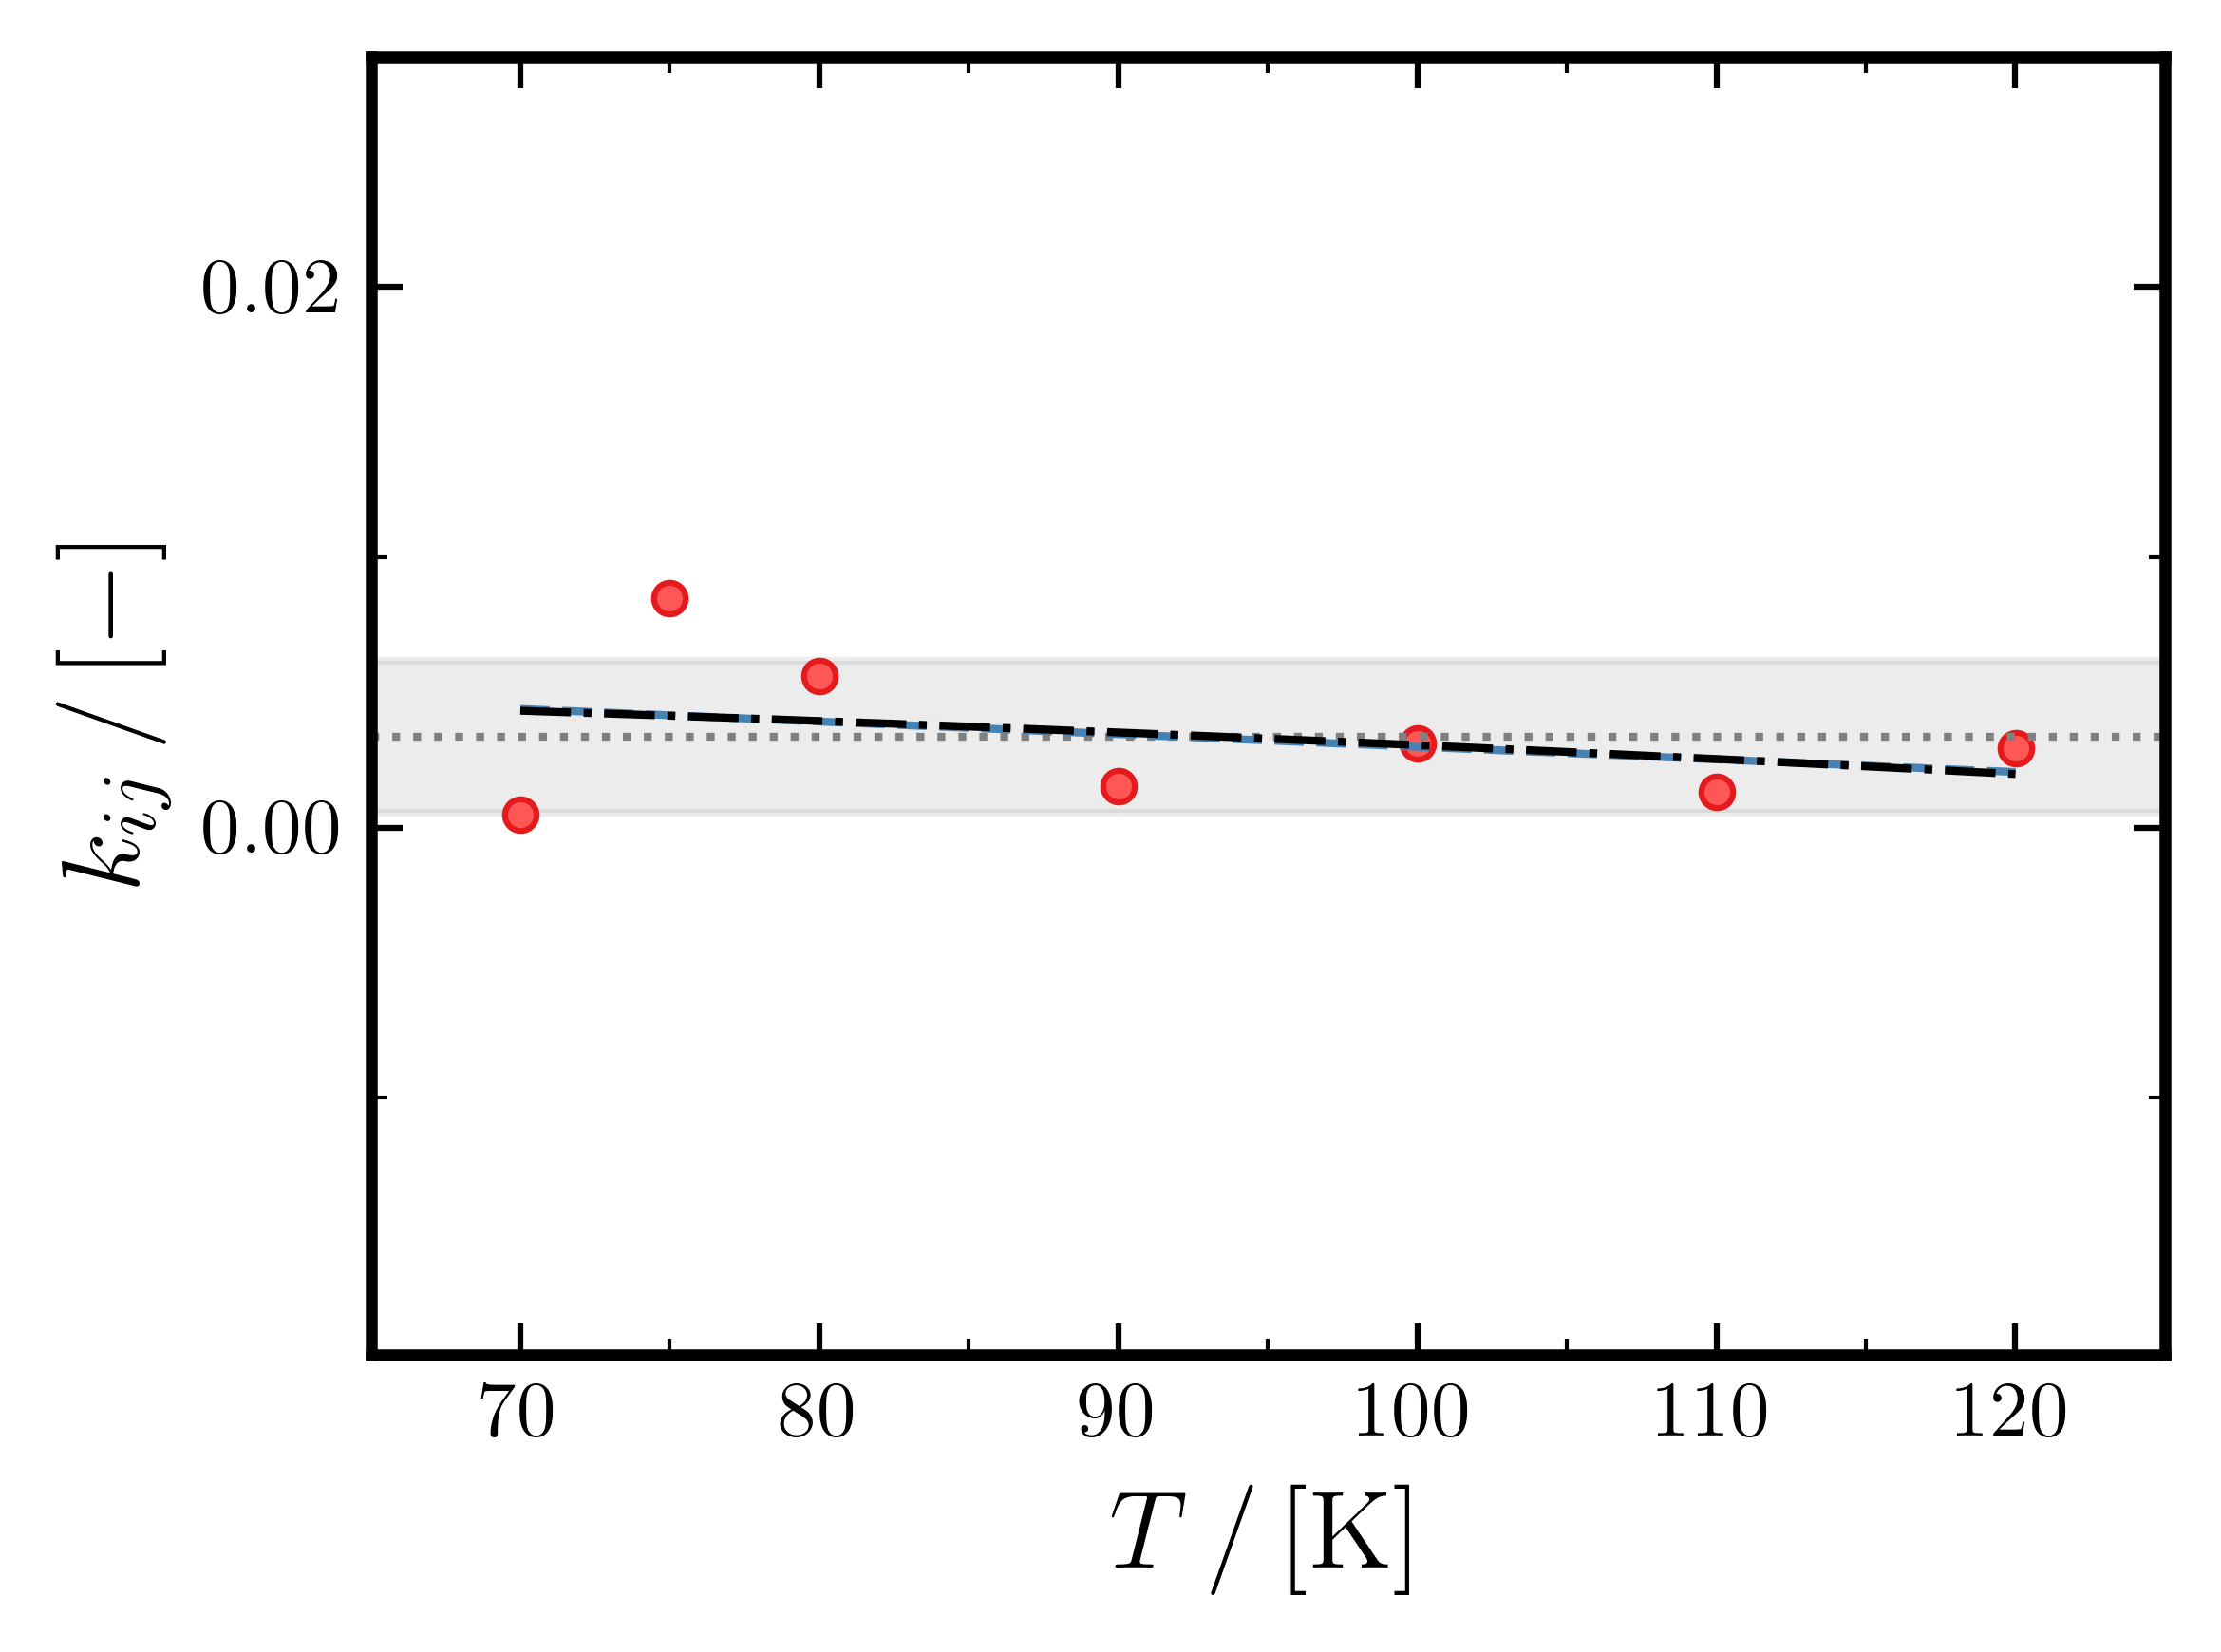

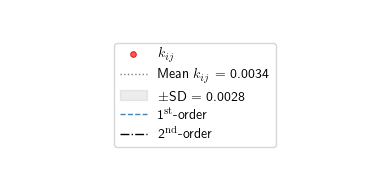

In [15]:
T_fit           = np.linspace(T_data.min(), T_data.max(), nfit)
kij_fit_lin     = kij_func_lin(T_fit)
kij_fit_quad    = kij_func_quad(T_fit)

fig1, ax1 = ps.plot_init()

ax1.plot(df_best_kij["Temperature_[K]"], df_best_kij["kij"],linestyle="",
    linewidth=ps.linewidth,marker=ps.markers[0],markersize=ps.markersize, markerfacecolor="#FF5656",
    markeredgewidth=ps.markeredgewidth,color=ps.colors[0],
    label=r"$k_{ij}$")

# Constant: mean and SD as horizontal band
ax1.axhline(kij_mean, color="gray", linewidth=ps.linewidth, linestyle=":",
    label=rf"Mean $k_{{ij}}$ = {kij_mean:.4f}")
ax1.axhspan(kij_mean - kij_std, kij_mean + kij_std,
    alpha=0.15, color="gray",
    label=rf"$\pm$SD = {kij_std:.4f}")

# Linear fit
ax1.plot(T_fit, kij_fit_lin, color="steelblue", linewidth=ps.linewidth, linestyle="--",
    label=r"1$^{\mathrm{st}}$-order")

# Quadratic fit
ax1.plot(T_fit, kij_fit_quad, color="k", linewidth=ps.linewidth, linestyle="-.",
    label=r"2$^{\mathrm{nd}}$-order")
    
ax1.set_xlabel(r"$T\,/\, \mathrm{[K]}$", fontsize=ps.label_fontsize)
ax1.set_ylabel(r"$k_{ij}\, / \, [-]$", fontsize=ps.label_fontsize)
# ps.style_legend(ax1, loc='lower left', ncol=1, borderaxespad=1.0, frame=True)

ax1.minorticks_on()
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax1.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(5))

ax1.set_xlim(T_data.min() - 5, T_data.max() + 5)
ax1.set_ylim(kij_data.min() - 0.02, kij_data.max() + 0.02)

fig1.tight_layout()
ps.save_plot(fig1, f"kij_{mixture.replace('-','-')}_vs_T")
plt.show()

# Separate legend figure
handles, labels = ax1.get_legend_handles_labels()
fig_leg, ax_leg = plt.subplots(figsize=(4, 2))
ax_leg.axis("off")
ax_leg.legend(handles, labels, loc="center", ncol=1, frameon=True)
fig_leg.tight_layout()
ps.save_plot(fig_leg, f"kij_{mixture.replace('-', '-')}_legend")
plt.show()

In [16]:
out = {
    "T_min": T_min,
    "T_max": T_max,
    "constant": {
        "deg"   : 0,
        "mean"  : kij_mean,
        "std"   : kij_std
    },
    "linear": {
        "deg"   : 1,
        "coeffs": [float(c) for c in coeffs_lin]
    },
    "quadratic": {
        "deg"   : 2,
        "coeffs": [float(c) for c in coeffs_quad]
    },
    "plots": {
        "kij_vs_T" : fig_to_b64(fig1),
        "legend"   : fig_to_b64(fig_leg)
    }
}

Path("KIJ.json").write_text(json.dumps(out, indent=2), encoding="utf-8")

32021

In [17]:
notebook_end = time.perf_counter()
print(f"Total notebook runtime: {notebook_end - notebook_start:.2f} s")

Total notebook runtime: 9.13 s
